In [1]:
import sys
sys.path.append('../src/training-on-CM2.6')
sys.path.append('../src/tensor_calculus')
import xarray as xr
import xgcm

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*Dataset.dims.*"
)

from helpers.plot_helpers import *
from helpers.selectors import *
from tensor_calculus import Tensor

%load_ext autoreload
%autoreload 3

In [2]:
def read_dataset(key='train'):
    base_path = '/scratch/zanna/data/cm2.6-Perezhogin-etal-2025/factor-4'

    selector = lambda x: x.sel(yh=slice(10, 50), xh=slice(-249.8,-130)).sel(yq=slice(10, 50), xq=slice(-249.8,-130)).isel(zl=0)
    
    # Read file with grid information
    depth_selector = lambda x: x.isel(zl=np.arange(0,50,5)) if len(x.zl)==50 else x
    static = selector(depth_selector(xr.open_mfdataset(f'{base_path}/param.nc'))).isel(zi=0)
    
    # Read time-dependent data
    data = selector(xr.open_mfdataset(f'{base_path}/{key}*.nc', chunks={'time':1, 'zl':1}, concat_dim='time', combine='nested').sortby('time'))

    # xgcm grid
    grid = xgcm.Grid(static, coords={
                'X': {'center': 'xh', 'right': 'xq'},
                'Y': {'center': 'yh', 'right': 'yq'}
            },
            boundary={"X": 'fill', 'Y': 'fill'},
            fill_value = {'Y':0, 'X':0})

    return data.astype('float64'), static.astype('float64'), grid

data, param, grid = read_dataset()

In [97]:
D0 = Tensor.init_vector(data.u_h, data.v_h, label="u_i")
D1 = D0.diff(param, grid)
D2 = D1.diff(param, grid)
#D3 = D2.diff(param, grid)
#D4 = D3.diff(param, grid)

D2.set_symmetric_indices(['j','k'])
# D3.set_symmetric_indices(['j','k', 'm'])
# D4.set_symmetric_indices(['j','k', 'm', 'n'])

In [98]:
tensor1 = (D1*D2).contract(['j','k']).contract(['i','n']).rename()

In [99]:
tensor2 = (D1*D2).perp('j').contract(['j','k']).perp('i').contract(['i','n']).rename()

In [100]:
tensor2._repr_latex_()

'$(\\partial_J^{\\perp}u_I^{\\perp})(\\partial_J\\partial_Iu_i)$'

In [101]:
tensor1.hash_array

<xarray.DataArray (i: 2)> Size: 16B
array([ 1.07420683, -0.51151204])
Dimensions without coordinates: i

In [102]:
tensor2.hash_array

<xarray.DataArray (i: 2)> Size: 16B
array([-0.11219462,  1.3130833 ])
Dimensions without coordinates: i

array([<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
       <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
      dtype=object)

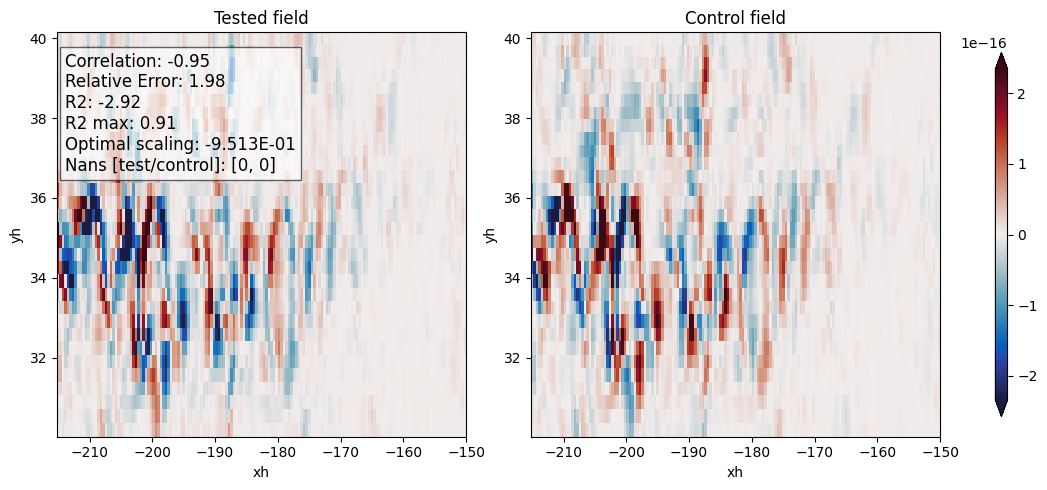

In [103]:
Pacific = lambda x: x.sel(xh=slice(-215,-150), yh=slice(30,40))
compare(tensor1.array.isel(time=0,i=0), tensor2.array.isel(time=0,i=0), selector=Pacific)

In [4]:
S2 = 0.5*(D2 + D2.transpose(['i', 'j']))
S2.label = '@_k%_{ij}'
O2 = D2 - S2
O2.label = '@_k&_{ij}'
S2

In [5]:
S1 = 0.5*(D1 + D1.transpose(['i', 'j']))
S1.label = '%_{ij}'
O1 = D1 - S1
O1.label = '&_{ij}'
S1

In [6]:
(D1-S1-O1).hash_array

<xarray.DataArray (i: 2, j: 2)> Size: 32B
array([[0., 0.],
       [0., 0.]])
Dimensions without coordinates: i, j

In [7]:
#vort = (Tensor.levi_civita() * D1).contract(['i', 'm']).contract(['j', 'k'])
vort_grad = (Tensor.levi_civita() * D2).contract(['i', 'k']).contract(['j', 'm'])

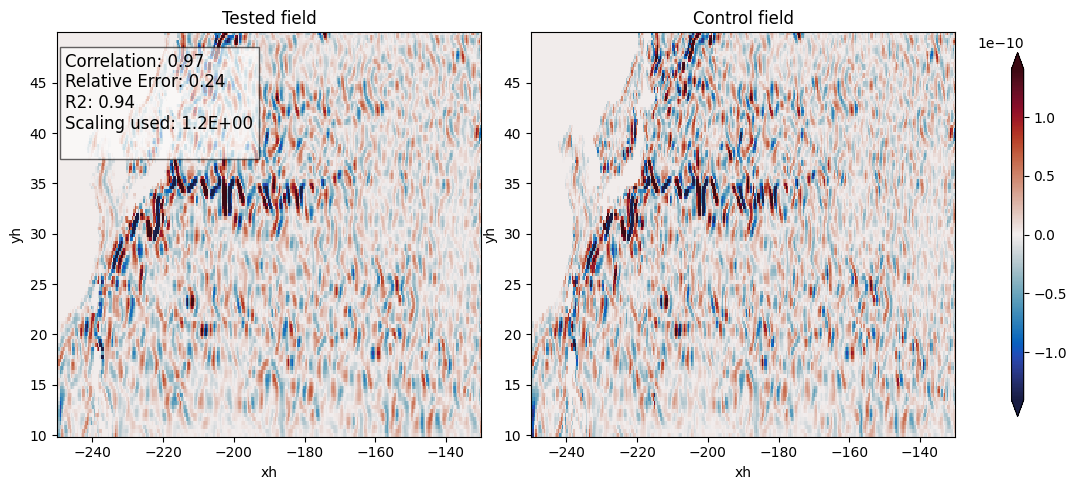

In [8]:
compare(vort_grad.array[0].isel(n=0), data.rel_vort_x[0], scale=True, selector=select_Pacific);

# Construct basis

In [56]:
from IPython.display import Math, display
from itertools import combinations_with_replacement

def print_basis(results):
    print('Library of tensors has length', len(results))
    for t in results:
        display(Math(f"{t.rename()._repr_latex_()}"))


def construct_basis_of_tensors(initial_tensors, their_derivatives=None, max_nonlinearity = 1, max_derivative=4, add_perp=False, add_advection=False, advection_nonlinearity=3):
    results = []

    for nonlinearity in range(1, max_nonlinearity+1):
        for idx in combinations_with_replacement(range(0, len(initial_tensors)), nonlinearity):
            tensor = initial_tensors[idx[0]]
            for i in range(1, len(idx)):
                tensor = tensor*initial_tensors[idx[i]]

            sum_derivative = sum([their_derivatives[idx] for idx in idx])
            if sum_derivative > max_derivative:
                continue
            #display(Math(tensor._repr_latex_()+ f'${sum_derivative}$'))

            results.extend(tensor.contract_to_rank_one(add_perp=add_perp))

    final_results = copy.deepcopy(results)

    if add_advection:
        for t in results:
            for tt in results:
                if t.label.count('@') + tt.label.count('@') < max_derivative:
                    if t.label.count('u') + tt.label.count('u') <= advection_nonlinearity:
                        final_results.append((t * tt.diff(param, grid)).contract(['i', 'j']).rename())


    return final_results

# Basis functions based on perpendicular operator and advection

In [57]:
basis = construct_basis_of_tensors([D0, D1, D2], 
                                    [0, 1, 2],
                                    max_nonlinearity=2)
print_basis(basis)

Library of tensors has length 15


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [60]:
basis = construct_basis_of_tensors([D0, D1, D2], 
                                    [0, 1, 2],
                                    max_nonlinearity=2, add_perp=False, add_advection=True)
print_basis(basis)

Library of tensors has length 56


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [47]:
basis = construct_basis_of_tensors([D0, D1, D2], 
                                    [0, 1, 2],
                                    max_nonlinearity=2, add_perp=True)
print_basis(basis)

Library of tensors has length 41


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [61]:
basis = construct_basis_of_tensors([D0, D1, D2], 
                                    [0, 1, 2],
                                    max_nonlinearity=2, add_perp=True, add_advection=True)
print_basis(basis)

Library of tensors has length 237


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [62]:
hashes = []
for t in basis:
    hashes.append(t.hash_array.values)

# Simple baselines

In [112]:
basis = []
basis.append(D4.contract_to_rank_one()[1].rename())

In [113]:
strain_rate = (S1*S1).contract(['i', 'k']).contract(['j', 'm']).sqrt()

basis.append((strain_rate * S1).diff(param, grid).contract(['k', 'j']).rename())

In [114]:
basis.append((strain_rate * S2.diff(param, grid).contract(['m','k'])).diff(param,grid).contract(['k','j']).rename())

In [115]:
vort_grad = (Tensor.levi_civita() * D2).contract(['i', 'k']).contract(['j', 'm'])

In [116]:
vort_grad_magnitude = (vort_grad * vort_grad).contract(['n', 'i']).sqrt()
basis.append((vort_grad_magnitude * S1).diff(param, grid).contract(['k','j']).rename())

In [117]:
basis.append((vort_grad_magnitude * S2.diff(param, grid).contract(['m','k'])).diff(param,grid).contract(['k','j']).rename())

In [118]:
basis[2]

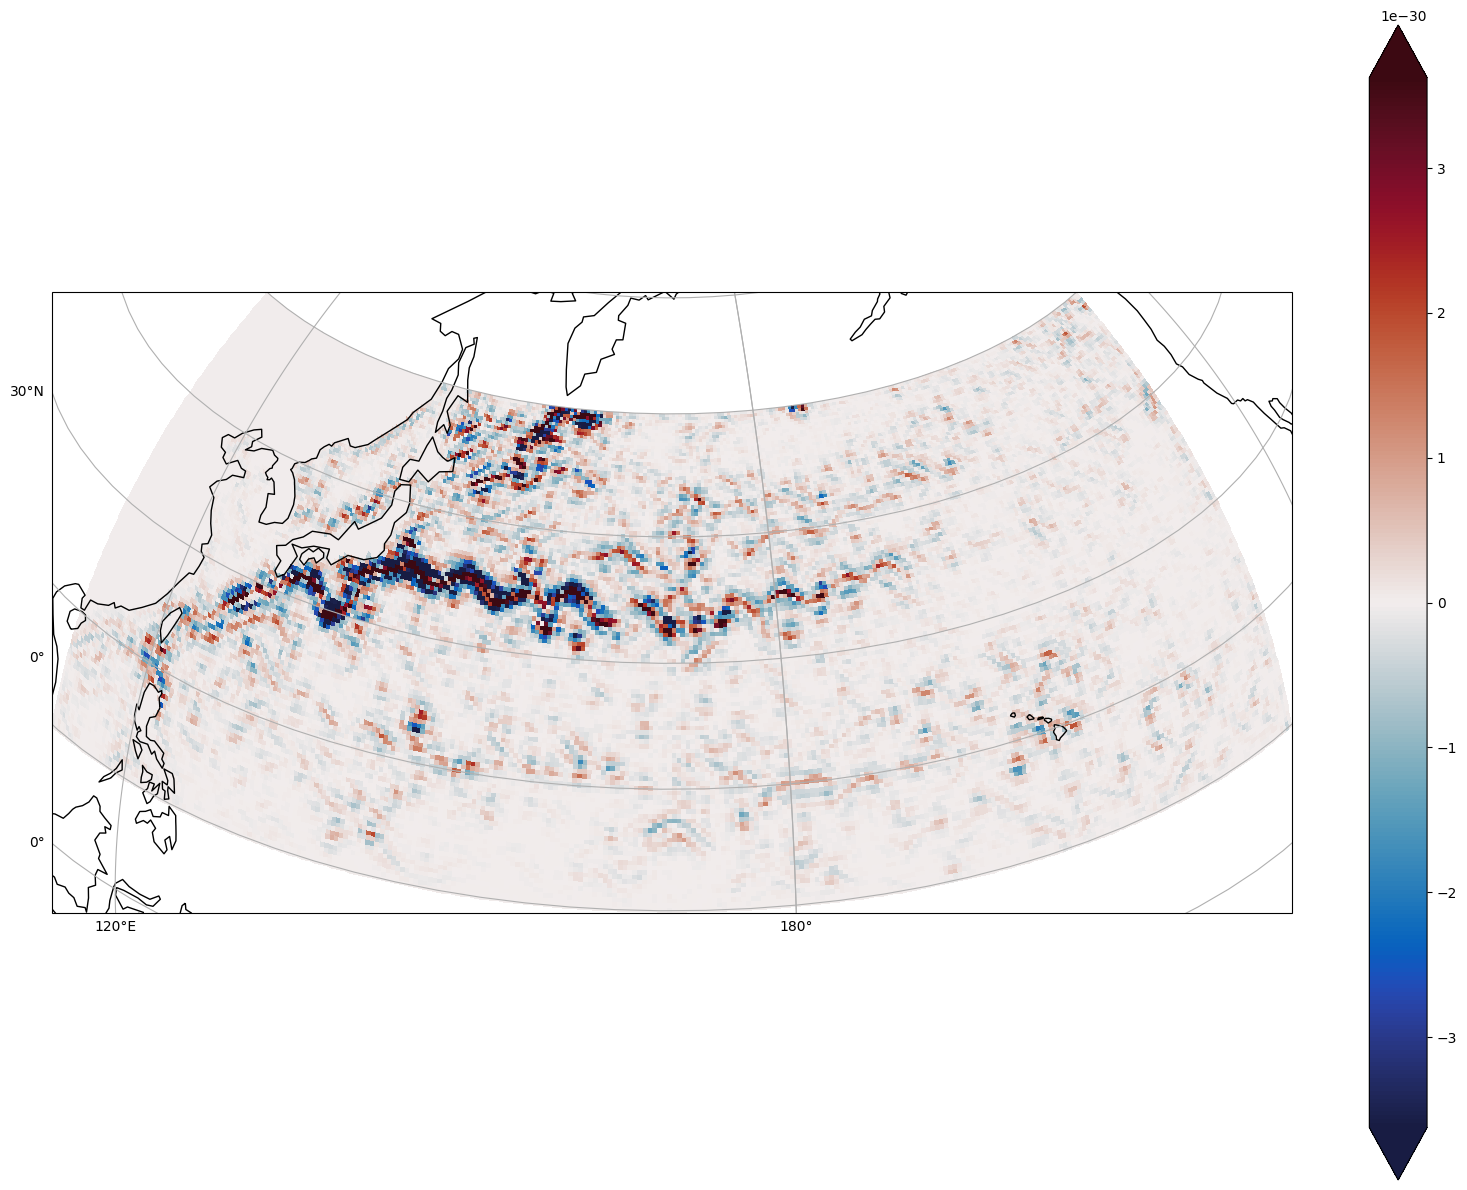

In [100]:
plot(basis[4].array.isel(time=0,i=0), selector=select_Pacific)

In [101]:
from tensor_calculus import transposition_data
SGS = transposition_data(xr.concat([data.SGSx_h, data.SGSy_h], dim='i'))
V = transposition_data(xr.concat([data.u_h, data.v_h], dim='i'))

In [102]:
import xrft
def cross_spectrum(SGS, V, dx_mean=1):    
    x = dx_mean*np.arange(len(SGS.xh))
    SGS['xh'] = x
    V['xh'] = x

    sp = xrft.cross_spectrum(SGS, V, dim='xh', window='hann', detrend='linear', true_phase=False)
    
    # Normalize to angular frequencies
    sp['freq_xh'] = sp['freq_xh'] * 2 * np.pi
    sp = sp / (2 * np.pi)
    sp = sp.sel(freq_xh=slice(1e-9,None))
    return np.real(sp).compute()

In [103]:
import xrft
def metrics(SGS, V):
    SGS_mean = SGS.mean('time').compute()
    V_mean = V.mean('time').compute()

    dEdt = (SGS * V).mean('time').compute()
    dEdt_mean = SGS_mean * V_mean
    dEdt_transient = dEdt - dEdt_mean

    selector = lambda x: x.sel(xh=slice(-215,-150), yh=slice(30,40))

    dx = float(selector(param.dxT).mean())
    
    transfer = cross_spectrum(selector(SGS), selector(V), dx).mean(['time', 'yh']).compute()
    transfer_mean = cross_spectrum(selector(SGS_mean), selector(V_mean), dx).mean(['yh']).compute()
    transfer_transient = transfer - transfer_mean
    
    return SGS_mean, dEdt, dEdt_mean, dEdt_transient, \
           transfer, transfer_mean, transfer_transient


In [129]:
SGS_mean, dEdt, dEdt_mean, dEdt_transient, transfer, transfer_mean, transfer_transient = metrics(SGS,V)

In [130]:
dataset = xr.Dataset()
dataset['SGS_mean'] = SGS_mean
dataset['dEdt'] = dEdt
dataset['dEdt_mean'] = dEdt_mean
dataset['dEdt_transient'] = dEdt_transient
dataset['transfer'] = transfer
dataset['transfer_mean'] = transfer_mean
dataset['transfer_transient'] = transfer_transient

In [131]:
dataset.astype('float64').to_netcdf(f'/scratch/pp2681/mom6/equation-discovery/Pacific_mean/9999.nc')

In [132]:
for index in range(5):
    idx = index + 1149
    tensor = basis[index]

    SGS_mean, dEdt, dEdt_mean, dEdt_transient, transfer, transfer_mean, transfer_transient = metrics(tensor.array,V)
    dataset = xr.Dataset()

    dataset[f'{idx}_SGS_mean'] = SGS_mean
    dataset[f'{idx}_dEdt'] = dEdt
    dataset[f'{idx}_dEdt_mean'] = dEdt_mean
    dataset[f'{idx}_dEdt_transient'] = dEdt_transient
    dataset[f'{idx}_transfer'] = transfer
    dataset[f'{idx}_transfer_mean'] = transfer_mean
    dataset[f'{idx}_transfer_transient'] = transfer_transient

    print(idx)
    print(tensor._repr_latex_())
    dataset[f'{idx}_SGS_mean'].attrs["long_name"] = tensor._repr_latex_()
    dataset.astype('float64').to_netcdf(f'/scratch/pp2681/mom6/equation-discovery/Pacific_mean/{idx}.nc')

1149
$\partial_M\partial_M\partial_J\partial_Ju_i$
1150
$\partial_K(\sqrt{(S_{IJ})(S_{IJ})})(S_{iK})$
1151
$\partial_K(\sqrt{(S_{IJ})(S_{IJ})})(\partial_M\partial_MS_{iK})$
1152
$\partial_K(\sqrt{((\varepsilon_{IJ})(\partial_I\partial_Nu_J))((\varepsilon_{IJ})(\partial_I\partial_Nu_J))})(S_{iK})$
1153
$\partial_K(\sqrt{((\varepsilon_{IJ})(\partial_I\partial_Nu_J))((\varepsilon_{IJ})(\partial_I\partial_Nu_J))})(\partial_M\partial_MS_{iK})$


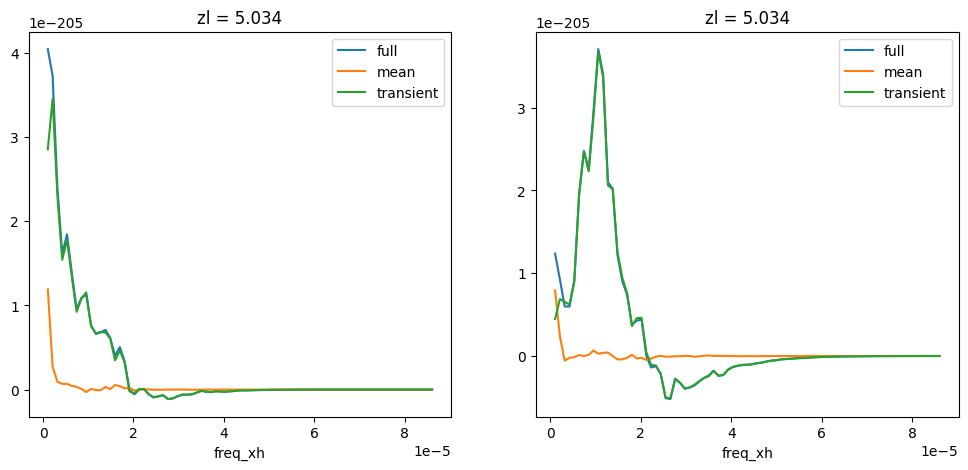

In [183]:
plt.figure(figsize=(12,5))
for i in range(2):
    plt.subplot(1,2,1+i)
    np.real(transfer.isel(i=i)).plot(label='full')
    np.real(transfer_mean.isel(i=i)).plot(label='mean')
    np.real(transfer_transient.isel(i=i)).plot(label='transient')
    #plt.xscale('log')
    plt.legend()

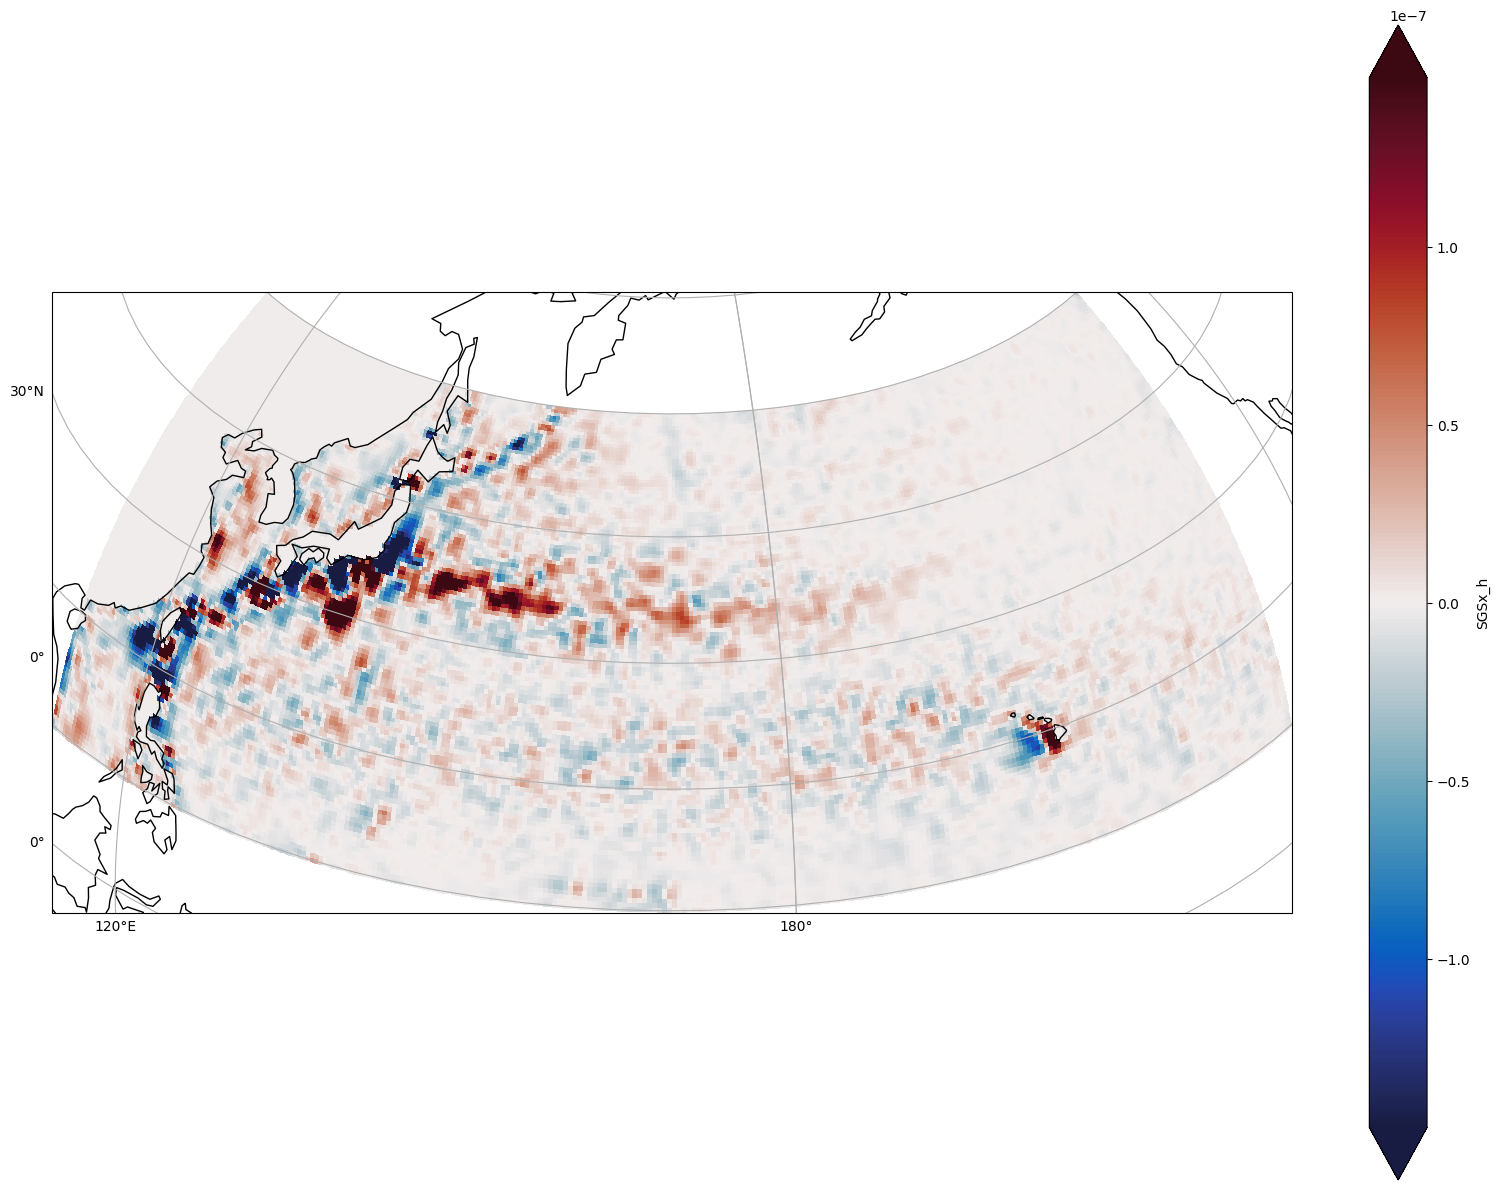

In [189]:
plot(SGS_mean.isel(i=0), selector=select_Pacific)

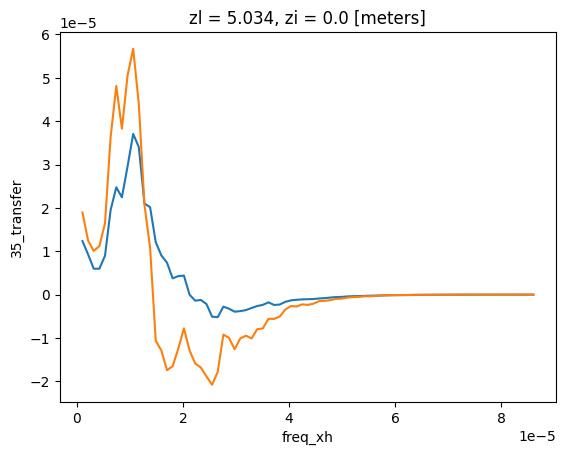

In [226]:
i = 35
basis = xr.open_dataset(f'/scratch/pp2681/mom6/equation-discovery/Pacific_mean/{i}.nc')
transfer.isel(i=1).plot()
(-1e+10*basis[f'{i}_transfer']).isel(i=1).plot()
#compare(basis[f'{i}_dEdt'], dEdt, selector=select_Pacific, scale=True)

# Save basis in a separate file for discovery

In [223]:
from tensor_calculus import transposition_data
SGS = transposition_data(xr.concat([data.SGSx_h, data.SGSy_h], dim='i'))
selector = lambda x: x.isel(time=[0,-1])

In [224]:
wet_nan = data.wet_nan
def filter_n(array, n=1):
    for i in range(n):
        array = grid.interp(array, ['X', 'Y'])
    return array

wet_nan10 = filter_n(wet_nan, 10)

In [225]:
dataset = xr.Dataset()
dataset['wet_nan'] = (wet_nan).compute()
dataset['wet_nan10'] = (wet_nan10).compute()
dataset['SGS'] = selector(SGS).compute()
dataset['SGS'].attrs["long_name"] = r"$\mathcal{S}$"

V = transposition_data(xr.concat([data.u_h, data.v_h], dim='i'))
dataset['V'] = selector(V).compute()
dataset['V'].attrs["long_name"] = '$u_i$'

In [235]:
for j, tensor in enumerate(basis):
    dataset[f'{j}'] = selector(tensor.array).compute()
    dataset[f'{j}'].attrs["long_name"] = tensor._repr_latex_()
    print(j)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42


: 

In [211]:
dataset.astype('float32').to_netcdf('equation-discovery/D4_quadratic.nc')

# Sequential regression

In [3]:
#ds = xr.open_dataset('/scratch/pp2681/mom6/equation-discovery/global_D4_quadratic.nc')
#set_of_features=[f'{i}' for i in range(70)]
ds = xr.open_dataset('/scratch/pp2681/mom6/equation-discovery/Pacific_D2_DD6_NN3.nc')
set_of_features=[f'{i}' for i in range(121)]

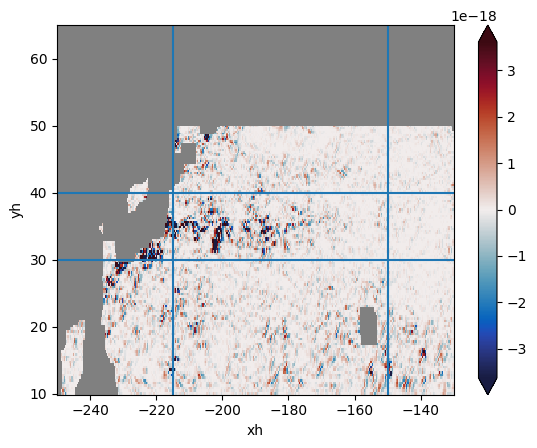

In [4]:
plot(ds.wet_nan10*ds['6'], selector=select_Pacific, cartopy=False)
plt.axhline(y=30)
plt.axhline(y=40)
plt.axvline(x=-215)
plt.axvline(x=-150)

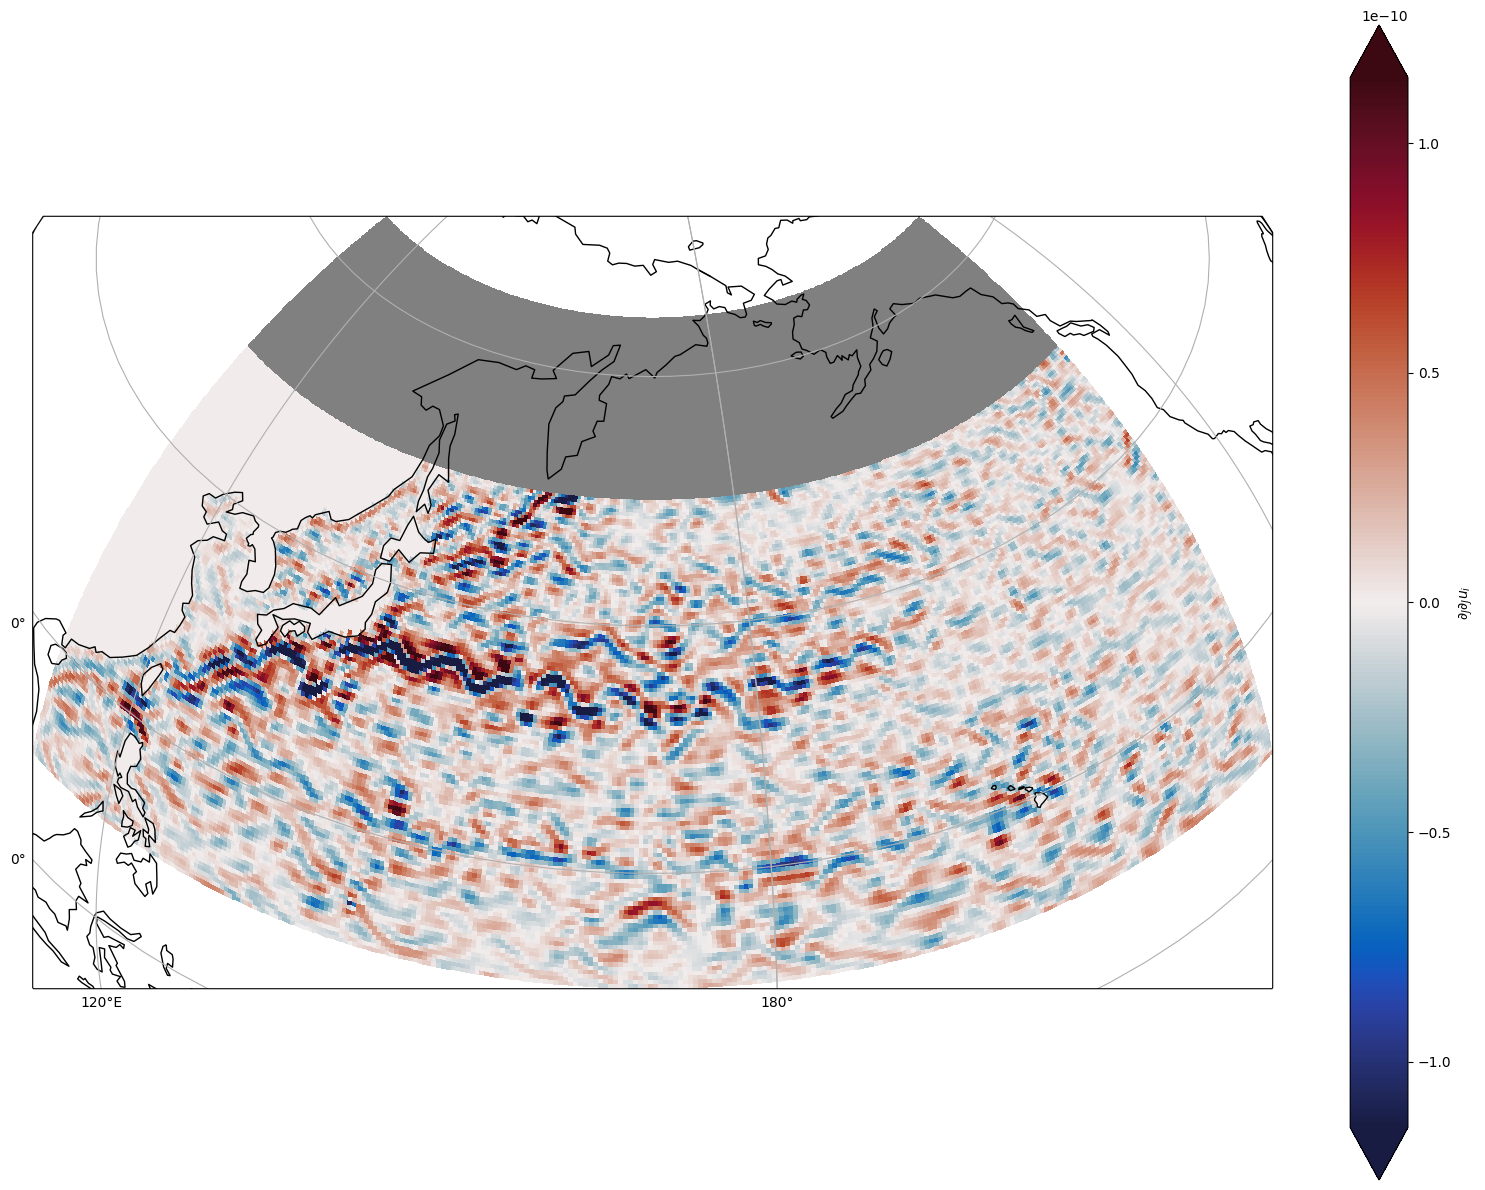

In [5]:
plot(ds['2'], selector=select_Pacific)

In [6]:
def corr(x,y):
    '''
    Not centered correlation as we do not have intercept
    in our linear model
    '''
    return float((x*y).mean() / np.sqrt((x**2).mean() * (y**2).mean()))

In [23]:
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.preprocessing import StandardScaler
from IPython.display import Math, display


NA = lambda x: x.sel(xh=slice(-50,-20), yh=slice(30,50))
Pacific = lambda x: x.sel(xh=slice(-215,-150), yh=slice(30,40))

def sequential_regression(dataset,
    set_of_features=None, 
    fetch_train = lambda ds, key: Pacific(ds[key]).isel(time=range(0,20)),
    fetch_test  = lambda ds, key: Pacific(ds[key]).isel(time=range(-20,0)),
    target_key = 'SGS',
    num_iterations = 1,
    show_top=1,
    max_derivative = 1,
    ):

    target = fetch_train(dataset, target_key)
    target_test = fetch_test(dataset, target_key)
    selected_features = []
    residual = target.copy()
    for iteration in range(num_iterations):
        # Compute correlation with residuals
        corrs = []
        for key in set_of_features:
            if dataset[key].long_name.count('\partial') <= max_derivative:
                feature = fetch_train(dataset, key).copy()
                feature_test = fetch_test(dataset, key).copy()
                corrs.append((key, feature, feature_test, np.abs(corr(feature, residual))))
        
        # Print top 5 correlations
        corrs.sort(key = lambda x: x[3], reverse=True)
        for i in range(min(show_top, len(corrs))):
            key, feature, feature_test, correlation = corrs[i]
            display(Math(dataset[key].long_name+f' correlation of tensor {key} with residual: ${correlation:.2f}$'))

        if (len(corrs) == 0):
            return
        # Select best feature
        selected_features.append((corrs[0][:3]))

        # Regression for a set of current features
        y = target.values.reshape(-1,1)
        y_test = target_test.values.reshape(-1,1)
        x = np.array([xx[1].values.reshape(-1) for xx in selected_features]).T
        x_test = np.array([xx[2].values.reshape(-1) for xx in selected_features]).T

        # Scaling features
        scaler_x = StandardScaler(with_mean=False)
        scaler_y = StandardScaler(with_mean=False)
        x_scaled = scaler_x.fit_transform(x)
        y_scaled = scaler_y.fit_transform(y)

        model = LinearRegression(fit_intercept=False)
        model.fit(x_scaled,y_scaled)

        y_pred = scaler_y.scale_ * model.predict(x_scaled)
        r2 = sklearn.metrics.r2_score(y, y_pred)

        x_test_scaled = scaler_x.transform(x_test)
        y_test_pred = scaler_y.scale_ * model.predict(x_test_scaled)
        r2_test = sklearn.metrics.r2_score(y_test, y_test_pred)
        
        print(f"Interation {iteration}: R squared [train/test]: [{r2:.4f},{r2_test:.4f}]")

        # Remove already used feature
        set_of_features.remove(corrs[0][0])
        # Update residual
        residual = target.copy() - y_pred.reshape(target.shape)

        print()
        

In [24]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=3, max_derivative = 6)

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.7719,0.7594]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7911,0.7776]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7960,0.7828]



In [31]:
import copy
set_of_features_filtered = copy.deepcopy(set_of_features)
set_of_features_filtered.remove('9')
set_of_features_filtered.remove('0')
sequential_regression(ds, set_of_features=set_of_features_filtered,
                      num_iterations=3, max_derivative = 6)

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.3508,0.3463]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7616,0.7513]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7854,0.7701]



In [12]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.8884,0.8537]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.8989,0.8697]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.9076,0.8805]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.9124,0.8905]



<IPython.core.display.Math object>

Interation 4: R squared [train/test]: [0.9137,0.8922]



In [13]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.7614,0.7422]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7851,0.7729]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7975,0.7814]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.8016,0.7835]



<IPython.core.display.Math object>

Interation 4: R squared [train/test]: [0.8048,0.7858]



In [14]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.8079,0.7371]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.8837,0.8010]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.8965,0.8398]



KeyboardInterrupt: 

In [ ]:
set_of_features_filtered = copy.deepcopy(set_of_features)
set_of_features_filtered.remove('9')
set_of_features_filtered.remove('0')
set_of_features_filtered.remove('3')
set_of_features_filtered.remove('30')
set_of_features_filtered.remove('6')
sequential_regression(ds, set_of_features=set_of_features_filtered,
                      num_iterations=10, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.5011,0.4957]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.6096,0.5653]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.6860,0.6327]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.7149,0.6312]



KeyboardInterrupt: 